In [38]:
import requests
import pandas as pd

url = "https://data.cityofnewyork.us/resource/eabe-havv.json"

LIMIT = 50000
all_data = []

for offset in range(0, 400000, LIMIT):
    print(f"  Fetching rows {offset:,} – {offset + LIMIT:,}...")
    params = {
        "$limit": LIMIT,
        "$offset": offset,
        "$order": "date_entered DESC"  
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    batch = response.json()
    if not batch:
        break
    all_data.extend(batch)

df = pd.DataFrame(all_data)
df["date_entered"] = pd.to_datetime(df["date_entered"])

complaints = df[(df["date_entered"] >= "2023-01-01") & (df["date_entered"] < "2026-01-01")].copy()

print(f"Downloaded: {df.shape}")
print(f"2023–2025 only: {complaints.shape}")
print(complaints["date_entered"].min(), "to", complaints["date_entered"].max())

  Fetching rows 0 – 50,000...
  Fetching rows 50,000 – 100,000...
  Fetching rows 100,000 – 150,000...
  Fetching rows 150,000 – 200,000...
  Fetching rows 200,000 – 250,000...
  Fetching rows 250,000 – 300,000...
  Fetching rows 300,000 – 350,000...
  Fetching rows 350,000 – 400,000...
Downloaded: (400000, 15)
2023–2025 only: (50243, 15)
2023-11-08 00:00:00 to 2025-12-31 00:00:00


In [39]:
print(complaints.shape)
print(complaints["date_entered"].min(), "to", complaints["date_entered"].max())
print(complaints["date_entered"].dt.year.value_counts().sort_index())

(50243, 15)
2023-11-08 00:00:00 to 2025-12-31 00:00:00
date_entered
2023    17065
2024    16550
2025    16628
Name: count, dtype: int64


In [40]:
complaints["date_entered"] = pd.to_datetime(complaints["date_entered"])
complaints["disposition_date"] = pd.to_datetime(complaints["disposition_date"], errors="coerce")

In [41]:
complaints["days_to_resolve"] = (
    complaints["disposition_date"] - complaints["date_entered"]
).dt.days

In [42]:
complaints["month_filed"] = complaints["date_entered"].dt.to_period("M")
complaints["year_filed"] = complaints["date_entered"].dt.year
complaints["month_num"] = complaints["date_entered"].dt.month

In [43]:
disposition_descriptions = {
    "A1": "Buildings Violation(s) Served", "A2": "Criminal Court Summons Served",
    "A3": "Full Stop Work Order Served", "A4": "Buildings Violation(s) and Criminal Court Summons Served",
    "A6": "Vacant/Open/Unguarded Structure – Violation(s) Issued", "A7": "Complaint Accepted by Padlock Unit",
    "A8": "OATH Violation Served", "A9": "OATH and DOB Violations Served",
    "AA": "HRP: Request for Corrective Action Issued", "AB": "HRP: Corrective Action Issued – Corrected",
    "AC": "HRP: Corrective Action Issued – Not Corrected",
    "B1": "Buildings Violation(s) Prepared – Attempt to Serve", "B2": "OATH Summons Prepared – Attempt to Serve",
    "C1": "Inspector Unable to Gain Access – 1st Attempt", "C2": "Inspector Unable to Gain Access – 2nd Attempt",
    "C3": "Access Denied – 1st Attempt", "C4": "Access Denied – 2nd Attempt",
    "C5": "AW: No Access – 1st Attempt", "C6": "AW: Access Denied – 1st Attempt",
    "C7": "AW: No Access – 2nd Attempt", "C8": "AW: Access Denied – 2nd Attempt",
    "D1": "Assigned to Construction Enforcement", "D2": "Assigned to Plumbing Unit",
    "D3": "Assigned to Elevator Unit", "D4": "Assigned to Construction Safety Compliance Unit",
    "D5": "Assigned to Emergency Response Team", "D6": "Assigned to Boiler Unit",
    "D7": "Assigned to Cranes and Derricks Unit", "D9": "Assigned to Electrical Unit",
    "EB": "Assigned to Façade Inspection Safety Program", "EC": "Assigned to Structurally Compromised Buildings Unit",
    "ED": "Assigned to Retaining Wall Unit", "EF": "Assigned to Mayor's Office of Special Enforcement",
    "EG": "Assigned to Quality of Life Unit", "EH": "Assigned to Concrete Enforcement Unit",
    "EJ": "Assigned to Construction Safety Enforcement", "EK": "Assigned to Real-Time Enforcement Unit",
    "EZ": "Assigned to Department of Investigation", "E1": "Assigned to Building Marshal's Office",
    "E2": "Assigned to Legal Affairs/Padlock Unit", "E3": "Assigned to Borough Office for Final Inspection",
    "E4": "Assigned to LL58/87 Unit (Handicap Access)", "E5": "Assigned to Center for Re-evaluation",
    "E6": "Assigned to Special Operations Unit", "E9": "Assigned to Stalled Sites Unit",
    "F1": "Referred to DEP", "F2": "Referred to DHCR", "F3": "Referred to DOHMH",
    "F5": "Referred to DOS", "F6": "Referred to DOT", "F7": "Referred to NYS Office of Real Properties",
    "F8": "Referred to HPD", "F9": "Referred to HUD",
    "G1": "Referred to Inspector General's Office", "G2": "Referred to Parks and Recreation",
    "G3": "Referred to TLC", "G4": "Referred to DCA", "G5": "Referred to NYPD",
    "G6": "Referred to FDNY", "G7": "Referred to MOSE", "G8": "Referred to NYCHA", "G9": "Referred to DCAS",
    "H1": "See Complaint Number", "H2": "Previously Inspected – Pre-BIS",
    "H3": "Violation Issued for Failure to Obey SWO", "H4": "Criminal Court Summons – Failure to Obey SWO",
    "H5": "Stop All Work/No TCAO",
    "I1": "Complaint Unsubstantiated", "I2": "No Violation Warranted at Time of Inspection",
    "I3": "Compliance Inspection Performed",
    "J1": "Follow-Up Inspection to be Scheduled", "J2": "Complaint Resolved by Periodic Inspection",
    "J3": "Reviewed – Inspection to Be Scheduled", "J4": "Follow-Up Scheduled for Hazardous Condition",
    "K1": "Insufficient Information/Unable to Locate Address", "K2": "Address Invalid",
    "K5": "Letter of Deficiency Issued", "K6": "Letter of Deficiency with Partial SWO",
    "K7": "Notification of Correction Received", "K8": "Correction Verified by DOB",
    "L1": "Partial Stop Work Order", "L2": "Stop Work Order Fully Rescinded", "L3": "Stop Work Order Partially Rescinded",
    "MA": "MARCH: No Enforcement Action Taken", "MB": "MARCH: Failure to Maintain Building",
    "MC": "MARCH: Contrary to Approved Plans", "MD": "MARCH: Exit Passage Obstructed",
    "ME": "MARCH: Exit Passage Obstructed – Full Vacate", "MF": "MARCH: Exit Passage Obstructed – Partial Vacate",
    "MG": "MARCH: Occupancy Contrary to C of O", "MH": "MARCH: No PA Permit – Full Vacate",
    "MI": "MARCH: No PA Permit – Partial Vacate", "MJ": "MARCH: Work Without a Permit",
    "MK": "MARCH: No PA Permit – Violation Issued", "ND": "Notice of Deficiency Issued",
    "P3": "Closure/Padlock Order Issued", "P4": "Closure/Padlock Order Rescinded",
    "Q1": "Compromised Structure: Report Required", "Q4": "Compromised Structure: Condition Remedied",
    "RA": "Commissioner's Order Issued", "RG": "Commissioner's Order: Remediation Completed",
    "RH": "Emergency Declaration Issued", "RI": "Immediate Emergency Declaration Issued",
    "RJ": "Emergency Declaration: Action Completed", "RK": "Unsafe Building: Violation Issued",
    "RL": "Unsafe Building: Action Completed", "R1": "Inspection: No Immediate Action Required",
    "S0": "All Work Completed", "S1": "Stalled: Excavation – No Immediate Threat",
    "S9": "Stalled: Emergency Declaration Filed",
    "UA": "CSC: Released from Site Safety – Complaint Closed", "UB": "CSC: Demo Signed Off – Complaint Closed",
    "U1": "CSC: Unable to Gain Access", "U2": "CSC: Construction Safety in Compliance",
    "V1": "PASS Inspection", "V2": "FAIL Inspection",
    "W1": "Violation Served for Disobeying Vacate Order", "WA": "Weather Related: No Action Necessary",
    "XX": "Administrative Closure",
    "X1": "Compliance Inspection – No Enforcement Action Required",
    "X3": "All Work Substantially Conforms to Plans",
    "Y1": "Full Vacate Order Served", "Y2": "Vacate Order Fully Rescinded",
    "Y3": "Partial Vacate Order Served", "Y4": "Vacate Order Partially Rescinded",
}

complaints["disposition_description"] = complaints["disposition_code"].map(disposition_descriptions)


In [44]:
def categorize_disposition(code):
    if pd.isna(code):
        return "No Disposition"
    code = str(code).strip().upper()
    if code in ["XX", "H1", "H2", "MA", "I1", "K1", "K2"]:
        return "Closed – No Action"
    elif code.startswith("A") or code in ["H3", "H4", "H5", "W1", "RK", "ND", "MB", "MC", "MD", "ME", "MF", "MG", "MH", "MI", "MJ", "MK"]:
        return "Violation / Enforcement Action"
    elif code.startswith("C") or code in ["U1", "WB"]:
        return "Access Denied"
    elif code.startswith("D") or code.startswith("E"):
        return "Assigned to Unit"
    elif code.startswith("F") or code.startswith("G"):
        return "Referred to Other Agency"
    elif code in ["S0", "K8", "RG", "RJ", "RL", "RV", "Q4", "L2", "UA", "UB", "V1", "X1", "X3", "Y2", "Y4", "I2", "I3", "J2"]:
        return "Resolved / Compliant"
    elif code in ["Y1", "Y3", "RH", "RI", "P3"]:
        return "Emergency / Vacate"
    else:
        return "Pending / Monitoring"

complaints["disposition_category"] = complaints["disposition_code"].apply(categorize_disposition)

In [45]:
complaints["resolved_in_30_days"] = (
    (complaints["days_to_resolve"].notna()) &
    (complaints["days_to_resolve"] <= 30)
).astype(int)

In [46]:
print(complaints.dtypes)
print("\ndisposition_category breakdown:")
print(complaints["disposition_category"].value_counts())

complaint_number                      str
status                                str
date_entered               datetime64[us]
house_number                          str
house_street                          str
zip_code                              str
bin                                   str
community_board                       str
complaint_category                    str
unit                                  str
disposition_date           datetime64[us]
disposition_code                      str
inspection_date                       str
dobrundate                            str
special_district                      str
days_to_resolve                   float64
month_filed                     period[M]
year_filed                          int32
month_num                           int32
disposition_description               str
disposition_category                  str
resolved_in_30_days                 int64
dtype: object

disposition_category breakdown:
disposition_category
Resolved

In [48]:
def get_borough(cb):
    try:
        first_digit = str(int(float(cb)))[0]
        return {
            "1": "Manhattan",
            "2": "Bronx",
            "3": "Brooklyn",
            "4": "Queens",
            "5": "Staten Island"
        }.get(first_digit, "Unknown")
    except:
        return "Unknown"

complaints["borough"] = complaints["community_board"].apply(get_borough)

table1 = complaints.groupby("borough")["days_to_resolve"].agg(
    complaint_count="count",
    min_days="min",
    median_days="median",
    max_days="max"
).sort_values("complaint_count", ascending=False)

print(table1)

               complaint_count  min_days  median_days  max_days
borough                                                        
Brooklyn                 17376       0.0         11.0     901.0
Queens                   13409       0.0         29.0     905.0
Manhattan                10006       0.0          3.0     882.0
Bronx                     7204       0.0          9.0     848.0
Staten Island             2001       0.0         14.0     894.0
Unknown                      1     116.0        116.0     116.0


In [54]:
complaint_category_descriptions = {
    "1": "ACCIDENT – Construction/Plumbing", "2": "ACCIDENT – To Public",
    "3": "Adjacent Buildings – Not Protected", "4": "After Hours Work – Illegal",
    "5": "Permit – None", "6": "CONSTRUCTION – Change Grade/Watercourse",
    "7": "CONSTRUCTION – Change Watercourse", "8": "Contractor's Sign – NONE",
    "9": "Debris – Excessive", "10": "Debris/Building – Falling or In Danger",
    "11": "DEMOLITION – No Permit", "12": "DEMOLITION – Unsafe/Illegal",
    "13": "Elevator In FDNY Readiness – NONE", "14": "Excavation – Undermining Adjacent Building",
    "15": "Fence – NONE/Inadequate/Illegal", "16": "Inadequate Support/Shoring",
    "17": "Material/Personnel Hoist – No Permit", "18": "Material Storage – Unsafe",
    "19": "Mechanical Demolition – Illegal",
    "1A": "Illegal Conversion Commercial to Dwelling", "1B": "Illegal Tree Removal",
    "1C": "Damage Assessment Request", "1D": "Con Edison Referral",
    "1E": "Suspended Scaffolds – No Permit/Dangerous", "1F": "Failure to Comply with Crane Inspection",
    "1G": "Stalled Construction Site", "1H": "Emergency Asbestos Response",
    "1L": "Gas Utility Referral", "1U": "Special Operations Compliance Inspection",
    "1V": "Electrical Enforcement Work Order", "1W": "Plumbing Enforcement Work Order",
    "1X": "Construction Enforcement Work Order", "1Y": "Enforcement Work Order",
    "1Z": "Enforcement Work Order",
    "20": "Landmark Building – Illegal Work", "21": "Safety Net/Guard Rail – Damaged/NONE",
    "22": "Safety Netting – NONE", "23": "Sidewalk Shed/Scaffold – Inadequate/No Permit",
    "24": "Sidewalk Shed – NONE", "25": "Warning Signs/Lights – NONE",
    "26": "Watchman – NONE", "27": "Auto Repair – Illegal",
    "28": "BUILDING – In Danger of Collapse", "29": "BUILDING – Vacant, Open and Unguarded",
    "2A": "Posted Notice or Order Removed/Tampered", "2B": "Failure to Comply with Vacate Order",
    "2C": "Smoking Ban – Smoking on Construction Site",
    "2F": "Building Under Structural Monitoring", "2G": "Advertising Sign/Billboard – Illegal",
    "2K": "Structurally Compromised Building", "2L": "Façade – Unsafe Notification",
    "2N": "COVID-19 Executive Order", "2P": "Façades Unit Compliance Inspection",
    "30": "Building Shaking/Vibrating/Structural Stability", "31": "Certificate of Occupancy – None/Illegal",
    "32": "C of O – Not Being Complied With", "33": "Commercial Use – Illegal",
    "34": "Compactor Room/Refuse Chute – Illegal", "35": "Curb Cut/Driveway – Illegal",
    "36": "Driveway/Carport – Illegal", "37": "Egress – Locked/Blocked/Improper",
    "38": "Egress – Exit Door Not Proper", "39": "Egress – No Secondary Means",
    "3A": "Unlicensed/Illegal Electrical Work In Progress", "3B": "Routine Inspection",
    "3C": "Plan Compliance Inspection", "3H": "DCP/BSA Compliance Inspection",
    "40": "Falling – Part of Building", "41": "Falling – Part of Building in Danger",
    "42": "Fence – Illegal", "43": "Structural Stability Affected",
    "44": "Fireplace/Wood Stove – Illegal", "45": "Illegal Conversion",
    "46": "PA Permit – None", "47": "PA Permit – Not Being Complied With",
    "48": "Residential Use – Illegal", "49": "Storefront/Business Sign – Illegal",
    "4A": "Illegal Hotel Rooms in Residential Buildings", "4B": "SEP – Professional Certification Audit",
    "4E": "Stalled Sites Tracking Complaint", "4G": "Illegal Conversion No Access Follow-Up",
    "4H": "V.E.S.T. Program", "4J": "M.A.R.C.H. Program",
    "4P": "Legal/Padlock Tracking Complaint",
    "50": "Sign Falling/Illegal Erection", "51": "Illegal Social Club",
    "52": "Sprinkler System – Inadequate", "53": "Vent/Exhaust – Illegal/Improper",
    "54": "Wall/Retaining Wall – Bulging/Cracked", "55": "Zoning: Non-Conforming",
    "56": "Boiler: Fumes/Smoke/Carbon Monoxide", "57": "Boiler: Illegal",
    "58": "Boiler: Defective/Inoperative/No Permit", "59": "Electrical Wiring: Defective/Exposed",
    "5F": "Compliance Inspection", "5G": "Unlicensed/Illegal Work In-Progress",
    "60": "Electrical Work: Improper", "61": "Electrical Work: Unlicensed In-Progress",
    "62": "Elevator: Danger Condition/Shaft Open", "63": "Elevator: Defective/Inoperative",
    "64": "Elevator Shaft: Open and Unguarded", "65": "Gas Hook-Up/Piping – Illegal or Defective",
    "66": "Plumbing Work – Illegal/No Permit", "67": "Crane: No Permit/License/Unsafe",
    "68": "Crane/Scaffold: Unsafe/Illegal Operations", "69": "Crane/Scaffold: Unsafe Installation",
    "6M": "Elevator: Multiple Devices on Property", "6S": "Elevator: Single Device on Property",
    "6V": "Tenant Safety Inspection", "6W": "Tenant Safety – Failure to Post/Distribute",
    "70": "Suspension Scaffold – No Work In-Progress", "71": "SRO: Illegal Work/No Permit",
    "72": "SRO: Change in Occupancy/Use", "73": "Failure to Maintain",
    "74": "Illegal Commercial Use in Residential Zone", "76": "Unlicensed Plumbing Work In-Progress",
    "77": "Contrary to Handicap Access Law", "78": "Privately Owned Public Space – Non-Compliance",
    "7F": "CSE: Tracking Compliance", "7G": "CSE: Sweep",
    "7J": "Work Without a Permit – Occupied Multiple Dwelling", "7K": "Local Law 188/17 Compliance Inspections",
    "80": "Elevator Not Inspected/Illegal/No Permit", "81": "Elevator: Accident",
    "82": "Boiler: Accident/Explosion", "83": "Construction: Contrary to Approved Plans",
    "84": "Façade: Defective/Cracking", "85": "Failure to Retain Water/Improper Drainage",
    "86": "Work Contrary to Stop Work Order", "87": "Request for Deck Safety Inspection",
    "88": "Safety Net/Guard Rail – Damaged/None (6 stories or less)",
    "89": "Accident – Cranes/Derricks/Suspension", "8A": "Construction Safety Compliance (CSC) Action",
    "90": "Unlicensed/Illegal Activity", "91": "Site Conditions Endangering Workers",
    "92": "Illegal Conversion of Manufacturing Space", "93": "Request for Retaining Wall Safety Inspection",
    "94": "Plumbing: Defective/Leaking/Not Maintained", "96": "Unlicensed Boiler/Electrical/Plumbing Work",
    "97": "Other Agency Jurisdiction", "98": "Refer to Operations for Determination", "99": "Other",
}

complaints["complaint_category_desc"] = complaints["complaint_category"].map(complaint_category_descriptions)


In [55]:
table2 = complaints.groupby("complaint_category_desc")["days_to_resolve"].agg(
    complaint_count="count",
    avg_days_to_close="mean"
).sort_values("complaint_count", ascending=False).head(15).round(1)

print(table2)

                                                    complaint_count  \
complaint_category_desc                                               
Illegal Conversion                                             5889   
Work Without a Permit – Occupied Multiple Dwelling             2879   
Elevator: Single Device on Property                            2725   
Boiler: Defective/Inoperative/No Permit                        2268   
Construction Enforcement Work Order                            1834   
Building Shaking/Vibrating/Structural Stability                1803   
Sidewalk Shed/Scaffold – Inadequate/No Permit                  1676   
Elevator: Multiple Devices on Property                         1593   
Construction: Contrary to Approved Plans                       1376   
Electrical Wiring: Defective/Exposed                           1261   
Construction Safety Compliance (CSC) Action                    1251   
Local Law 188/17 Compliance Inspections                        1218   
CSE: T

In [56]:
table3 = complaints.groupby(["borough", "disposition_category"]).size().unstack(fill_value=0)

table3_pct = table3.div(table3.sum(axis=1), axis=0).mul(100).round(1)

print(table3_pct)

disposition_category  Access Denied  Assigned to Unit  Closed – No Action  \
borough                                                                     
Bronx                          13.6               0.1                 7.0   
Brooklyn                       19.5               0.2                 7.4   
Manhattan                       9.5               0.4                 6.7   
Queens                         31.8               0.1                 5.3   
Staten Island                  19.8               0.0                 6.4   
Unknown                         0.0               0.0               100.0   

disposition_category  Emergency / Vacate  No Disposition  \
borough                                                    
Bronx                                1.7             0.6   
Brooklyn                             1.1             0.5   
Manhattan                            0.5             0.6   
Queens                               1.4             0.3   
Staten Island          

In [57]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [59]:
monthly = complaints.groupby("month_filed").size().reset_index(name="complaint_count")
monthly["month_dt"] = monthly["month_filed"].dt.to_timestamp()

In [60]:
x = np.arange(len(monthly))
z = np.polyfit(x, monthly["complaint_count"], 1)
p = np.poly1d(z)

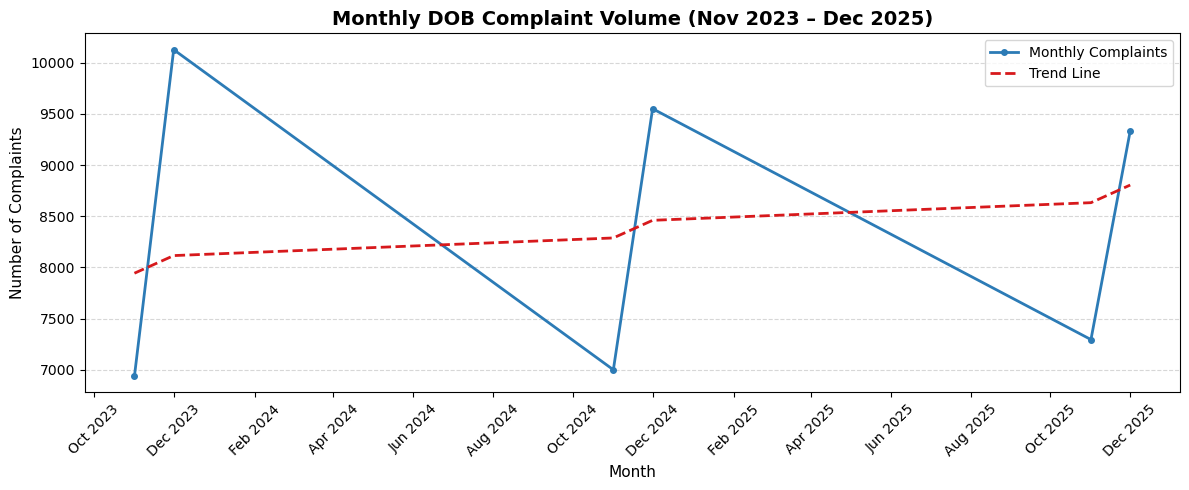

In [62]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly["month_dt"], monthly["complaint_count"], 
        color="#2c7bb6", linewidth=2, marker="o", markersize=4, label="Monthly Complaints")
ax.plot(monthly["month_dt"], p(x), 
        color="#d7191c", linewidth=2, linestyle="--", label="Trend Line")

ax.set_title("Monthly DOB Complaint Volume (Nov 2023 – Dec 2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Number of Complaints", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [65]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

chart2_data = complaints.groupby("complaint_category_desc")["days_to_resolve"].agg(
    complaint_count="count",
    avg_days="mean"
).sort_values("complaint_count", ascending=False).head(15).round(1)

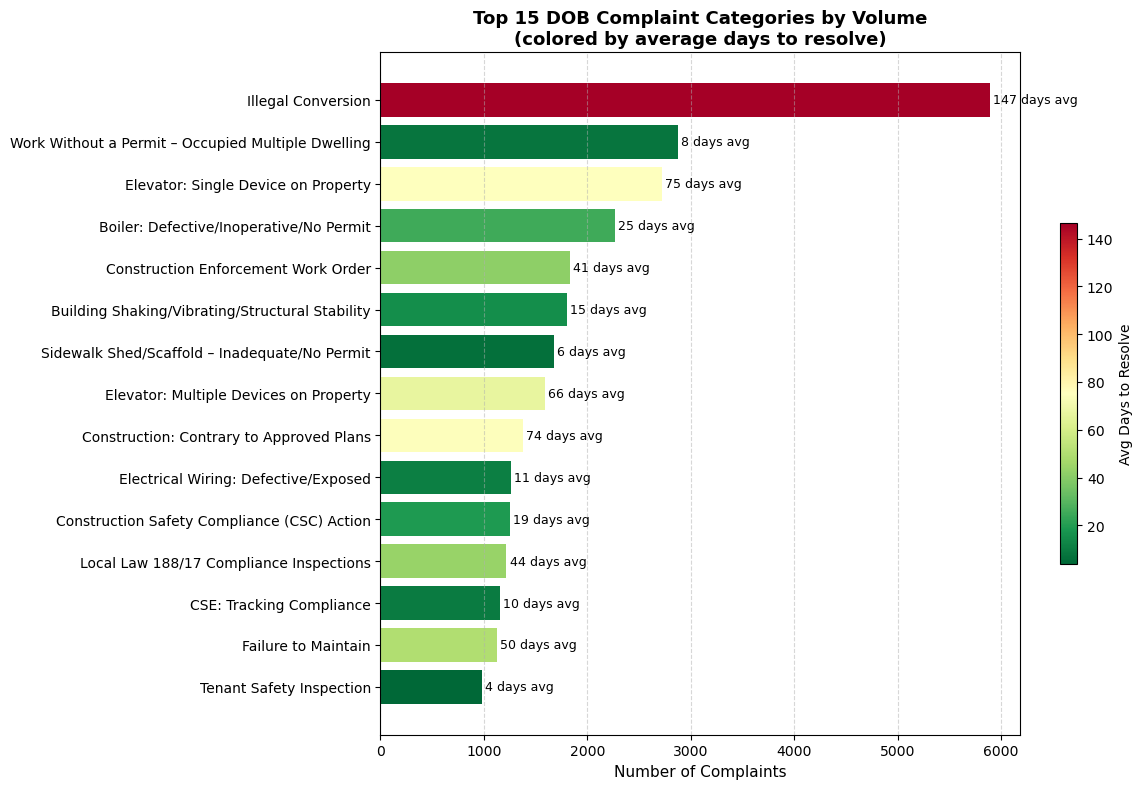

In [67]:
colors = cm.RdYlGn_r(
    (chart2_data["avg_days"] - chart2_data["avg_days"].min()) /
    (chart2_data["avg_days"].max() - chart2_data["avg_days"].min())
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(chart2_data.index, chart2_data["complaint_count"], color=colors)

for bar, avg in zip(bars, chart2_data["avg_days"]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f"{avg:.0f} days avg", va="center", fontsize=9)

ax.set_title("Top 15 DOB Complaint Categories by Volume\n(colored by average days to resolve)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Complaints", fontsize=11)
ax.set_ylabel("")
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.5)

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r",
     norm=plt.Normalize(chart2_data["avg_days"].min(), chart2_data["avg_days"].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Avg Days to Resolve", shrink=0.5)

plt.tight_layout()
plt.show()

In [71]:
import plotly.express as px
import requests

In [82]:
geojson_url = "https://raw.githubusercontent.com/fedhere/PUI2015_EC/master/mam1612_EC/nyc-zip-code-tabulation-areas-polygons.geojson"
geo = requests.get(geojson_url).json()

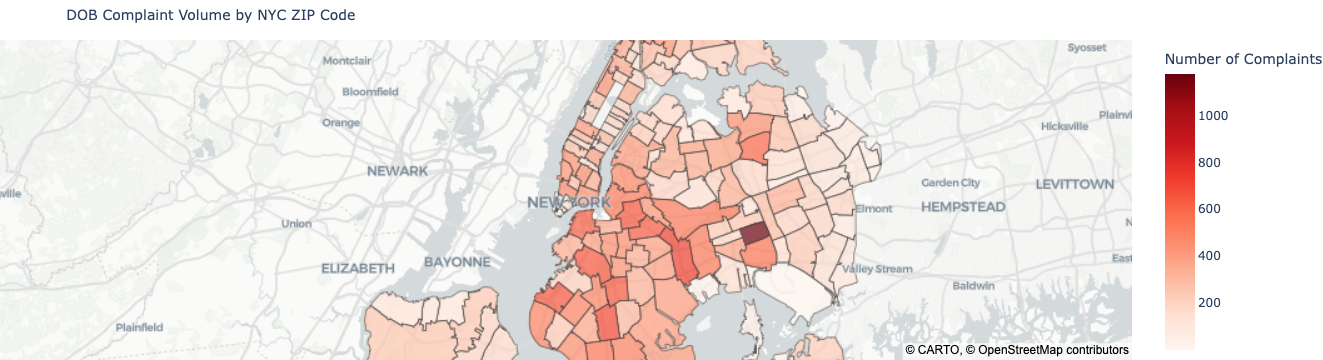

In [85]:
zip_data = complaints.groupby("zip_code").agg(
    complaint_count=("complaint_number", "count"),
    avg_days=("days_to_resolve", "mean"),
    borough=("borough", "first")
).reset_index().round(1)

fig = px.choropleth_map(
    zip_data,
    geojson=geo,
    locations="zip_code",
    featureidkey="properties.postalCode",
    color="complaint_count",
    hover_name="zip_code",
    hover_data={"borough": True, "avg_days": True, "complaint_count": True},
    color_continuous_scale="Reds",
    map_style="carto-positron",
    zoom=9.5,
    center={"lat": 40.7128, "lon": -74.0060},
    opacity=0.7,
    title="DOB Complaint Volume by NYC ZIP Code",
    labels={
        "complaint_count": "Number of Complaints",
        "avg_days": "Avg Days to Resolve",
        "borough": "Borough",
        "zip_code": "ZIP Code"
    }
)

fig.update_layout(
    title_font_size=14,
    margin={"r": 0, "t": 40, "l": 0, "b": 0}
)

fig.show()

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

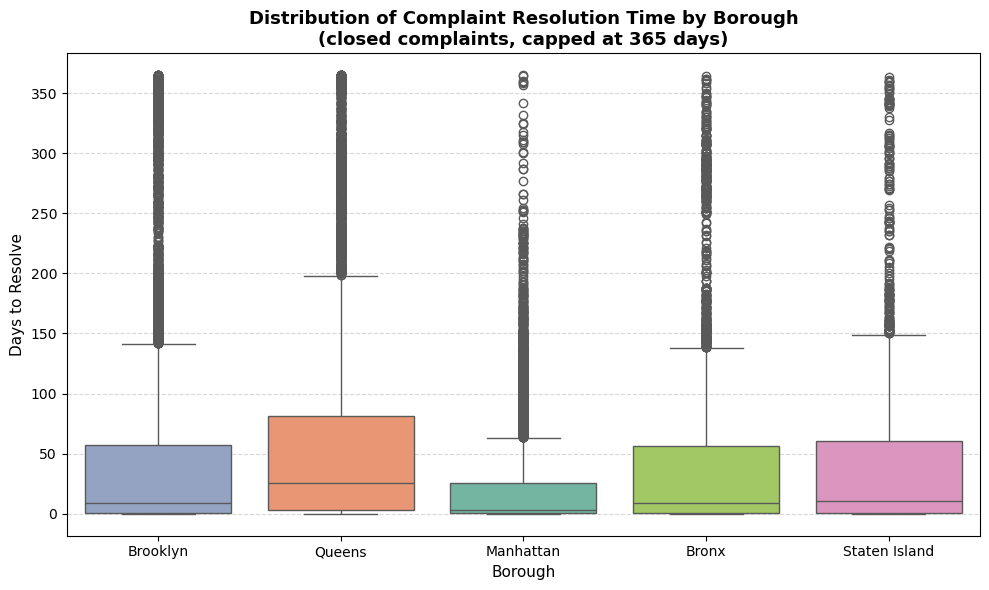

In [88]:
chart4_data = complaints[
    (complaints["days_to_resolve"].notna()) & 
    (complaints["days_to_resolve"] <= 365) &
    (complaints["borough"] != "Unknown")
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=chart4_data,
    x="borough",
    y="days_to_resolve",
    hue="borough",
    legend=False,
    palette="Set2",
    order=["Brooklyn", "Queens", "Manhattan", "Bronx", "Staten Island"],
    ax=ax
)

ax.set_title("Distribution of Complaint Resolution Time by Borough\n(closed complaints, capped at 365 days)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Borough", fontsize=11)
ax.set_ylabel("Days to Resolve", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
import pandas as pd
import numpy as np

In [91]:
model_df = complaints[complaints["days_to_resolve"].notna()].copy()

le_borough = LabelEncoder()
le_category = LabelEncoder()

model_df["borough_enc"] = le_borough.fit_transform(model_df["borough"])
model_df["category_enc"] = le_category.fit_transform(model_df["complaint_category"])
model_df["month_num"] = model_df["date_entered"].dt.month

In [92]:
features = ["borough_enc", "category_enc", "month_num"]
X = model_df[features]
y = model_df["resolved_in_30_days"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression: Predict Resolved Within 30 Days ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

=== Logistic Regression: Predict Resolved Within 30 Days ===

Accuracy:  0.537
Precision: 0.645
Recall:    0.564
ROC-AUC:   0.546

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.49      0.45      3796
           1       0.65      0.56      0.60      6204

    accuracy                           0.54     10000
   macro avg       0.53      0.53      0.52     10000
weighted avg       0.56      0.54      0.54     10000



In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [97]:
model2_df = complaints[complaints["days_to_resolve"].notna()].copy()
model2_df = model2_df[model2_df["days_to_resolve"] <= 365]  # cap outliers

model2_df["borough_enc"] = le_borough.transform(model2_df["borough"])
model2_df["category_enc"] = le_category.transform(model2_df["complaint_category"])

X2 = model2_df[["borough_enc", "category_enc", "month_num"]]
y2 = model2_df["days_to_resolve"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X2_train, y2_train)
y2_pred = lin_reg.predict(X2_test)

print("=== Linear Regression: Predict Days to Resolution ===\n")
print(f"R²:   {r2_score(y2_test, y2_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y2_test, y2_pred):.1f} days")
print(f"RMSE: {mean_squared_error(y2_test, y2_pred)**.5:.1f} days")

coef_df = pd.DataFrame({
    "feature": ["borough", "complaint_category", "month"],
    "coefficient": lin_reg.coef_
})
print("\nCoefficients:")
print(coef_df)

=== Linear Regression: Predict Days to Resolution ===

R²:   0.008
MAE:  49.0 days
RMSE: 71.1 days

Coefficients:
              feature  coefficient
0             borough     4.860073
1  complaint_category    -0.078916
2               month    -2.487236
